#### Load Packages

In [80]:
#data structures
import pandas as pd
import numpy as np
np.random.seed(42)

#figures
import seaborn as sns
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

#Plot Settings
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

#machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier   # Working classifier Felipe

#metrics (performace and machine learning scores)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

import time #used for seeing how long it takes to run programs

#### From HOML for figures
- Create the images/decision_trees folder (if it doesn't already exist), and define the save_fig() function which is used through this notebook to save the figures in high-res for the book:

In [82]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees_EarthQ"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

#### Read Data 
- Main Data Frames to work with

In [84]:
train_val = pd.read_csv('train_values.csv') #The data values of each building
train_labels = pd.read_csv('train_labels.csv') #labels of data as damage severity ('damage_grade')
test_val = pd.read_csv('test_values.csv') #data values of contest submition 

# combined features target label & Features for data sampling and other transformations
df_train = pd.merge(train_val, train_labels, on='building_id')

#### Check Data df_train + Explanation of columns:

In [86]:
df_train.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [87]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

0) building_id  

1) geo_level_1_id (type: int): level 1: 0-30, 

2) geo_level_2_id (type: int): level 2: 0-1427

3) geo_level_3_id (type: int): level 3: 0-12567

    Descript >>  Geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.

4) count_floors_pre_eq (type: int): number of floors in the building before the earthquake.

5) age (type: int): age of the building in years.

6) area_percentage (type: int): normalized area of the building footprint.

7) height_percentage (type: int): normalized height of the building footprint.

8) land_surface_condition (type: categorical): surface condition of the land where the building was built. Possible values: n, o, t.

9) foundation_type (type: categorical): type of foundation used while building. Possible values: h, i, r, u, w.

10) roof_type (type: categorical): type of roof used while building. Possible values: n, q, x.

11) ground_floor_type (type: categorical): type of the ground floor. Possible values: f, m, v, x, z.

12) other_floor_type (type: categorical): type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.

13) position (type: categorical): position of the building. Possible values: j, o, s, t.

14) plan_configuration (type: categorical): building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.

15) has_superstructure_adobe_mud (type: binary): flag variable that indicates if the superstructure was made of Adobe/Mud.

16) has_superstructure_mud_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Stone.

17) has_superstructure_stone_flag (type: binary): flag variable that indicates if the superstructure was made of Stone.

18) has_superstructure_cement_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Stone.

19) has_superstructure_mud_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Brick.

20) has_superstructure_cement_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Brick.

21) has_superstructure_timber (type: binary): flag variable that indicates if the superstructure was made of Timber.

22) has_superstructure_bamboo (type: binary): flag variable that indicates if the superstructure was made of Bamboo.

23) has_superstructure_rc_non_engineered (type: binary): flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.

24) has_superstructure_rc_engineered (type: binary): flag variable that indicates if the superstructure was made of engineered reinforced concrete.

25) has_superstructure_other (type: binary): flag variable that indicates if the superstructure was made of any other material.

26) legal_ownership_status (type: categorical): legal ownership status of the land where building was built. Possible values: a, r, v, w.

27) count_families (type: int): number of families that live in the building.

28) has_secondary_use (type: binary): flag variable that indicates if the building was used for any secondary purpose.

29) has_secondary_use_agriculture (type: binary): flag variable that indicates if the building was used for agricultural purposes.

30) has_secondary_use_hotel (type: binary): flag variable that indicates if the building was used as a hotel.

31) has_secondary_use_rental (type: binary): flag variable that indicates if the building was used for rental purposes.

32) has_secondary_use_institution (type: binary): flag variable that indicates if the building was used as a location of any institution.

33) has_secondary_use_school (type: binary): flag variable that indicates if the building was used as a school.

34) has_secondary_use_industry (type: binary): flag variable that indicates if the building was used for industrial purposes.

35) has_secondary_use_health_post (type: binary): flag variable that indicates if the building was used as a health post.

36) has_secondary_use_gov_office (type: binary): flag variable that indicates if the building was used fas a government office.

37) has_secondary_use_use_police (type: binary): flag variable that indicates if the building was used as a police station.

38) has_secondary_use_other (type: binary): flag variable that indicates if the building was secondarily used for other purpose

39) damage_grade 
 

#### Damage Grade Count + Mini visual Plot  

In [90]:
df_train['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

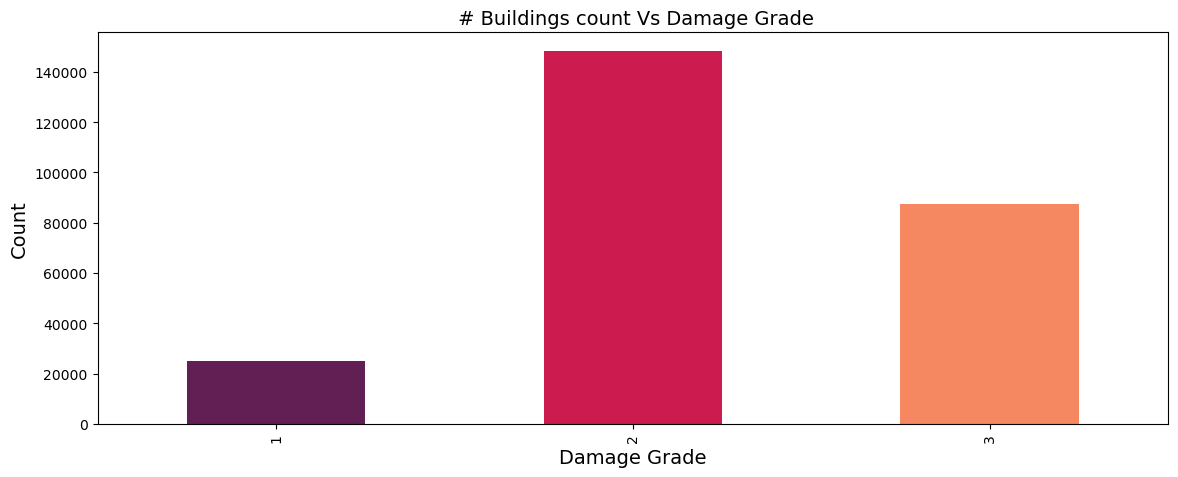

In [91]:
counts = train_labels.damage_grade.value_counts().sort_index()
colors = sns.color_palette("rocket", n_colors=len(counts))
ax = counts.plot.bar(figsize=(12,5), color=colors)
ax.set_title(" # Buildings count Vs Damage Grade")
ax.set_xlabel("Damage Grade")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

#### Reduced DataSet  
- From 'df_train' and 'test_val'
- TO 'sm' Set (Xtr_sm + ytr_sm + Xts_sm )

The idea here is to remove non relevant features following Structural principles for a building.
ie, the secondary use is not relevant to evaluate a building structural or foundations capabilities.
ie, the legal ownership is not relevant to structural capabilities neither...
Etc...

I have worked here only numerical features We can include others but need to be encoded, I dont know yet how to encod them properly
Planed list to be dropped  :
['damage_grade', 'building_id','legal_ownership_status','count_families','has_secondary_use'
                        ,'has_secondary_use_agriculture','has_secondary_use_hotel', 'has_secondary_use_rental'
                        ,'has_secondary_use_institution','has_secondary_use_school', 'has_secondary_use_industry'
                        ,'has_secondary_use_health_post','has_secondary_use_gov_office','has_secondary_use_use_police'
                        , 'has_secondary_use_other' ]

In [93]:
#df2 = df[['Courses', 'Fee']].copy()
# to reduced train
Xtr_sm = df_train[['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq'
                          , 'age','area_percentage', 'height_percentage']].copy()
ytr_sm = df_train[['damage_grade']].copy()

# to test
Xts_sm = test_val[['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq'
                          , 'age','area_percentage', 'height_percentage']].copy()

#### Check data info on Xtr_sm + ytr_sm Set

In [95]:
Xtr_sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   geo_level_1_id       260601 non-null  int64
 1   geo_level_2_id       260601 non-null  int64
 2   geo_level_3_id       260601 non-null  int64
 3   count_floors_pre_eq  260601 non-null  int64
 4   age                  260601 non-null  int64
 5   area_percentage      260601 non-null  int64
 6   height_percentage    260601 non-null  int64
dtypes: int64(7)
memory usage: 13.9 MB


In [96]:
ytr_sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 1 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   damage_grade  260601 non-null  int64
dtypes: int64(1)
memory usage: 2.0 MB


#### Split Dataset

In [98]:
X_train, X_val, y_train, y_val = train_test_split(
    Xtr_sm,
    ytr_sm,
    test_size=0.2,
    random_state=42,
    stratify= ytr_sm
)

### 6 Branches Train sm set +  predict sm set

In [100]:
# Train
tree_clf_sm = DecisionTreeClassifier(max_depth=6, random_state=42) # initialize
tree_clf_sm.fit(X_train, y_train)                                  # Fit

DecisionTreeClassifier(max_depth=6, random_state=42)

In [101]:
# Predict
tree_sm_preds = tree_clf_sm.predict(X_val) # Predict

#### From HOML ** This code example generates Figure Decision Tree:**

In [103]:
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf_sm,
        out_file=str(IMAGES_PATH / "EQ_Dtree.dot"),  # path 
        feature_names=['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age','area_percentage', 'height_percentage'],
        class_names=['DamageGrade1','DamageGrade2','DamageGrade3'],
        rounded=True,
        filled=True
    )

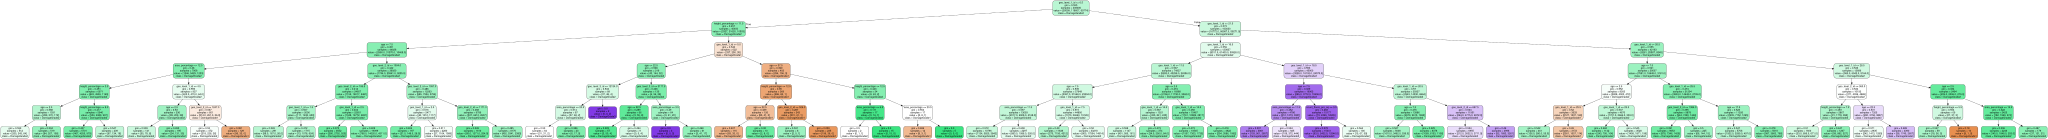

In [104]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "EQ_Dtree.dot")  # path 

In [105]:
# extra code
!dot -Tpng {IMAGES_PATH / "EQ_Dtree.dot"} -o {IMAGES_PATH / "EQ_Dtree.png"}

#### Evaluation

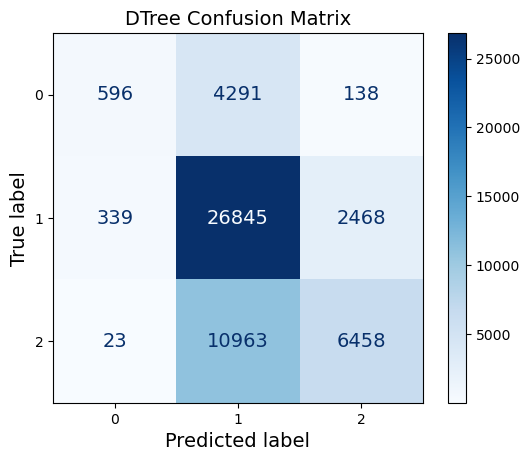

In [107]:
cm = confusion_matrix(y_val, tree_sm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("DTree Confusion Matrix")
plt.show()

In [108]:
rf_f1 = f1_score(y_val, tree_sm_preds, average='micro')
print("Decision tree with Validation F1:", rf_f1)

Decision tree with Validation F1: 0.650390437635502


In [127]:
# Evaluation metrics for Decision Tree
dt_metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_val, tree_sm_preds),
    "Precision": precision_score(y_val, tree_sm_preds, average='micro'),
    "Recall": recall_score(y_val, tree_sm_preds, average='micro'),
    "F1 Score": f1_score(y_val, tree_sm_preds,average='micro'),
} 

# AUC for multiclass: need predicted probabilities and multi_class param
y_prob = tree_clf_sm.predict_proba(X_val)  # or use predict_proba on validation features
dt_metrics["AUC"] = roc_auc_score(y_val, y_prob, multi_class='ovr', average='macro')


print(dt_metrics,"\n","Confusion Matrixxx:\n", cm)


{'Model': 'Decision Tree', 'Accuracy': 0.650390437635502, 'Precision': 0.650390437635502, 'Recall': 0.650390437635502, 'F1 Score': 0.650390437635502, 'AUC': 0.7622527346568703} 
 Confusion Matrixxx:
 [[  596  4291   138]
 [  339 26845  2468]
 [   23 10963  6458]]


### 12 Branches Train sm set +  predict sm set

In [132]:
# Train
tree_clf_sm12 = DecisionTreeClassifier(max_depth=12, random_state=42) # initialize
tree_clf_sm12.fit(X_train, y_train)      

DecisionTreeClassifier(max_depth=12, random_state=42)

In [134]:
# Predict
tree_sm_preds12 = tree_clf_sm12.predict(X_val) # Predict

#### Evaluation With 12 Branches

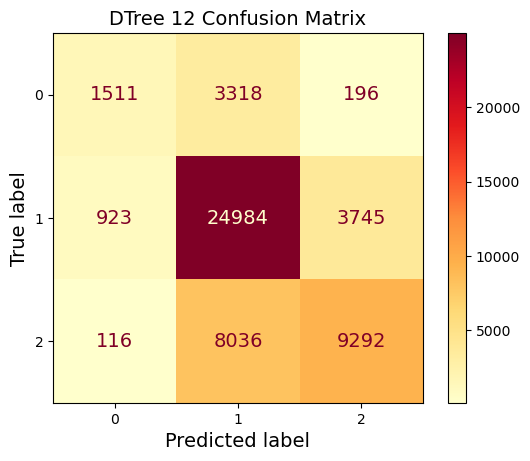

In [139]:
cm12 = confusion_matrix(y_val, tree_sm_preds12)
ConfusionMatrixDisplay(confusion_matrix=cm12).plot(cmap='YlOrRd')
plt.title("DTree 12 Confusion Matrix")
plt.show()

In [141]:
rf12_f1 = f1_score(y_val, tree_sm_preds12, average='micro')
print("Decision tree 12 Branches with Validation F1:", rf12_f1)

Decision tree 12 Branches with Validation F1: 0.6866138408702827


In [143]:
# Evaluation metrics for Decision Tree

dt12_metrics = {
    "Model": "Decision Tree 12",
    "Accuracy 12": accuracy_score(y_val, tree_sm_preds12),
    "Precision 12": precision_score(y_val, tree_sm_preds12, average='micro'),
    "Recall 12": recall_score(y_val, tree_sm_preds12, average='micro'),
    "F1 Score 12": f1_score(y_val, tree_sm_preds12,average='micro'),
} 

# AUC for multiclass: need predicted probabilities and multi_class param
y_prob12 = tree_clf_sm12.predict_proba(X_val)  # or use predict_proba on validation features
dt12_metrics["AUC"] = roc_auc_score(y_val, y_prob12, multi_class='ovr', average='macro')


print(dt_metrics,"\n","Confusion Matrix 12 :\n", cm12)


{'Model': 'Decision Tree', 'Accuracy': 0.650390437635502, 'Precision': 0.650390437635502, 'Recall': 0.650390437635502, 'F1 Score': 0.650390437635502, 'AUC': 0.7622527346568703} 
 Confusion Matrix 12 :
 [[ 1511  3318   196]
 [  923 24984  3745]
 [  116  8036  9292]]
